In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import random


In [3]:
# ====================================================
# Bagian 1: K-Means Clustering
# ====================================================

# 1. Memuat Dataset
file_path = 'AirQualityUCI.csv'  # Pastikan file dataset sesuai
data = pd.read_csv(file_path, sep=';')


In [5]:
# 2. Pra-pemrosesan Dataset
# Mengganti koma dengan titik dan mengubah ke tipe numerik
data_cleaned = data.replace(',', '.', regex=True)

# Memilih kolom yang relevan untuk clustering
columns_to_use = ["CO(GT)", "NOx(GT)", "NO2(GT)", "PT08.S5(O3)"]  # Parameter kualitas udara
data_cleaned = data_cleaned[columns_to_use].apply(pd.to_numeric, errors='coerce')

# Membersihkan data dari nilai NaN dan angka negatif
data_cleaned = data_cleaned.dropna()
data_cleaned = data_cleaned[(data_cleaned > 0).all(axis=1)]

# Reset indeks
data_cleaned.reset_index(drop=True, inplace=True)

In [7]:
# 3. Implementasi K-Means Clustering
k = 3  # Jumlah cluster
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(data_cleaned)

# Menambahkan hasil clustering ke dataset
data_cleaned["Cluster"] = kmeans.labels_


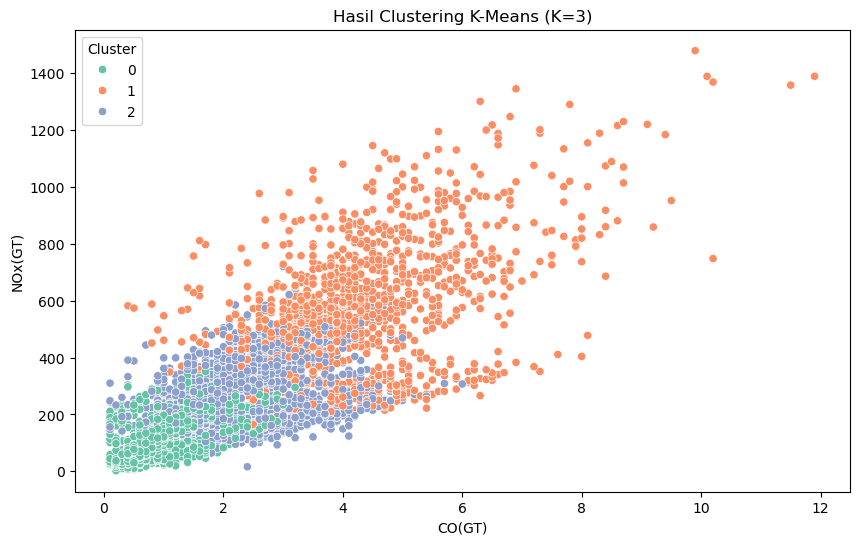

Inertia (SSD): 328540787.1538365


In [9]:
# 4. Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data_cleaned[columns_to_use[0]],
    y=data_cleaned[columns_to_use[1]],
    hue=data_cleaned["Cluster"],
    palette="Set2"
)
plt.title("Hasil Clustering K-Means (K=3)")
plt.xlabel(columns_to_use[0])
plt.ylabel(columns_to_use[1])
plt.show()

# Evaluasi model dengan inertia
print(f"Inertia (SSD): {kmeans.inertia_}")


In [11]:
# ====================================================
# Bagian 2: Q-Learning
# ====================================================

# 1. Membuat Lingkungan Penempatan Stasiun Udara
n_rows, n_cols = 5, 5  # Ukuran grid
grid = np.zeros((n_rows, n_cols))

# Menentukan reward berdasarkan skenario
high_pollution_areas = [(0, 4), (3, 3), (4, 2)]  # Polusi tinggi (+10)
high_population_areas = [(0, 2), (2, 2), (4, 4)]  # Populasi tinggi (+5)
existing_stations = [(1, 1), (3, 1)]  # Lokasi dengan stasiun terdekat (-5)
low_priority_areas = [(2, 0), (1, 4)]  # Lokasi tidak penting (-10)

# Atur reward pada grid
for loc in high_pollution_areas:
    grid[loc] += 10  # Prioritas tinggi
for loc in high_population_areas:
    grid[loc] += 5  # Tambahan untuk populasi tinggi
for loc in existing_stations:
    grid[loc] -= 5  # Hindari redundansi
for loc in low_priority_areas:
    grid[loc] -= 10  # Lokasi tidak relevan


In [23]:
# ====================================================
# Parameter Q-Learning
# ====================================================
n_actions = 4  # Aksi: Atas, Bawah, Kiri, Kanan
q_table = np.zeros((n_rows, n_cols, n_actions))
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.2  # Eksplorasi vs Eksploitasi
max_steps = 50  # Maksimal langkah per episode
n_episodes = 1000  # Jumlah episode pelatihan

# Fungsi untuk menentukan langkah berdasarkan aksi
def take_action(state, action):
    x, y = state
    if action == 0 and x > 0:  # Atas
        return (x - 1, y)
    elif action == 1 and x < n_rows - 1:  # Bawah
        return (x + 1, y)
    elif action == 2 and y > 0:  # Kiri
        return (x, y - 1)
    elif action == 3 and y < n_cols - 1:  # Kanan
        return (x, y + 1)
    return state

# Fungsi untuk menghitung reward tambahan
def calculate_reward(state, steps_taken, visited):
    reward = grid[state]
    if state in visited:
        reward -= 1  # Penalti untuk looping
    if steps_taken >= max_steps:
        reward -= 10  # Penalti jika melampaui batas langkah
    return reward

# Fungsi untuk memilih aksi
def get_next_action(state, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, n_actions - 1)  # Eksplorasi
    else:
        return np.argmax(q_table[state])  # Eksploitasi


In [25]:
# ====================================================
# Pelatihan Q-Learning
# ====================================================
for episode in range(n_episodes):
    state = (0, 0)  # Mulai dari pojok kiri atas
    visited = set()  # Lokasi yang telah dikunjungi
    for step in range(max_steps):
        visited.add(state)
        action = get_next_action(state, epsilon)
        next_state = take_action(state, action)

        # Hitung reward
        reward = calculate_reward(next_state, step, visited)

        # Update Q-Table
        old_q_value = q_table[state][action]
        next_max = np.max(q_table[next_state])
        new_q_value = old_q_value + alpha * (reward + gamma * next_max - old_q_value)
        q_table[state][action] = new_q_value

        # Pindah ke state berikutnya
        state = next_state

        # Jika lokasi dengan reward >= 10 tercapai, hentikan episode
        if grid[state] >= 10:
            break


In [27]:
# ====================================================
# Evaluasi dan Visualisasi
# ====================================================
print("\nQ-Table setelah pelatihan:")
print(q_table)

print("\nGrid Reward:")
print(grid)



Q-Table setelah pelatihan:
[[[31.51053105 28.16862687 31.44439279 36.23747438]
  [35.34309946 26.62325074 31.53413764 40.38740441]
  [40.         35.45318875 35.33913788 35.68004061]
  [34.99957849 31.62084744 40.          9.99987296]
  [ 0.          0.          0.          0.        ]]

 [[31.53432423 -3.18966144  9.68597097  6.78473365]
  [35.3036987  19.3104817  17.73912943 26.41373914]
  [40.         36.36922142 26.61391483 31.54804423]
  [18.21177881 13.69844242 35.17006889 -3.9288989 ]
  [ 6.5132156   0.          0.         -0.6782969 ]]

 [[14.26378723 -0.1        -2.05203065  4.36184885]
  [ 2.13854455 -1.43123228 -1.32110357 33.56552048]
  [35.05902185  9.82548613 16.89655425 14.64757035]
  [ 2.9812792   1.9        31.3629588   0.        ]
  [-1.          0.          0.          0.        ]]

 [[-1.51390289 -0.439561   -0.4900995  -0.5       ]
  [-0.1        -0.1        -0.1167309   2.04524918]
  [24.53103164  0.         -0.49523228  0.        ]
  [ 0.          0.          0.